In [14]:
#TP4 - K-MEANS : Segmentation Strategique (Modele RFM)
## Phase 1 : Acquisition et Ingestion
### Q1 - Collecte : TElecharger le dataset Online Retail

In [15]:
import pandas as pd
import time

t1 = time.time()
df = pd.read_csv(r'C:\Users\HP COR I5 7TH GEN\Desktop\CSV\online_retail_II.csv', 
                 encoding='latin-1')
t2 = time.time()

print(f"CSV load time: {t2-t1:.2f}s")
print(f"Shape: {df.shape}")
df.head()

CSV load time: 3.02s
Shape: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [17]:
### Q2 - Formats :Comparer CSV vs Parquet

In [18]:
df.to_parquet(r'C:\Users\HP COR I5 7TH GEN\Desktop\CSV\online_retail.parquet', index=False)

t3 = time.time()
df2 = pd.read_parquet(r'C:\Users\HP COR I5 7TH GEN\Desktop\CSV\online_retail.parquet')
t4 = time.time()

print(f"CSV:     {t2-t1:.2f}s")
print(f"Parquet: {t4-t3:.2f}s")
print(f"Parquet est plus rapide: {(t2-t1)/(t4-t3):.1f}x")
print("Parquet est privilegie car plus rapide et compresse mieux les donnees")

CSV:     3.02s
Parquet: 1.46s
Parquet est plus rapide: 2.1x
Parquet est privilegie car plus rapide et compresse mieux les donnees


In [ ]:
## Phase 2 : Data Cleaning (Le defi du monde reel)
### Q3 - Analyse des manquants

In [20]:
# Pourcentage de valeurs nulles par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

result = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print(result[result['Valeurs manquantes'] > 0])

             Valeurs manquantes  Pourcentage (%)
Description                4382             0.41
Customer ID              243007            22.77


In [21]:
### Q4 - Nettoyage metier

In [22]:
print(f"Avant nettoyage: {df.shape}")

# supprimer les lignes sans CustomerID
df = df.dropna(subset=['Customer ID'])

# supprimer les transactions annulees (Quantity <= 0)
df = df[df['Quantity'] > 0]

# supprimer les prix negatifs ou nuls
df = df[df['Price'] > 0]

print(f"Apres nettoyage: {df.shape}")
print(f"Lignes supprimees: {1067371 - len(df)}")

Avant nettoyage: (1067371, 8)
Apres nettoyage: (805549, 8)
Lignes supprimees: 261822


In [23]:
### Q5 - Ingenierie de base : Creation de la variable MontantTotal

In [24]:
# MontantTotal = Quantity x UnitPrice
df['MontantTotal'] = df['Quantity'] * df['Price']

print("Variable MontantTotal creee avec succes!")
print(df[['Quantity', 'Price', 'MontantTotal']].head())

Variable MontantTotal creee avec succes!
   Quantity  Price  MontantTotal
0        12   6.95          83.4
1        12   6.75          81.0
2        12   6.75          81.0
3        48   2.10         100.8
4        24   1.25          30.0


In [26]:
## Phase 3 : Feature Engineering (Transformation RFM)

In [27]:
import datetime

# Date de reference = Max Date + 1
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
date_ref = df['InvoiceDate'].max() + datetime.timedelta(days=1)
print(f"Date de reference: {date_ref}")

# Calcul RFM
rfm = df.groupby('Customer ID').agg(
    Recence=('InvoiceDate', lambda x: (date_ref - x.max()).days),
    Frequence=('Invoice', 'nunique'),
    Montant=('MontantTotal', 'sum')
).reset_index()

print(rfm.shape)
rfm.head()

Date de reference: 2011-12-10 12:50:00
(5878, 4)


,Customer ID,Recence,Frequence,Montant
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [28]:
### Q6 - Analyse de la distribution : Tracez l'histogramme de la variable Montant

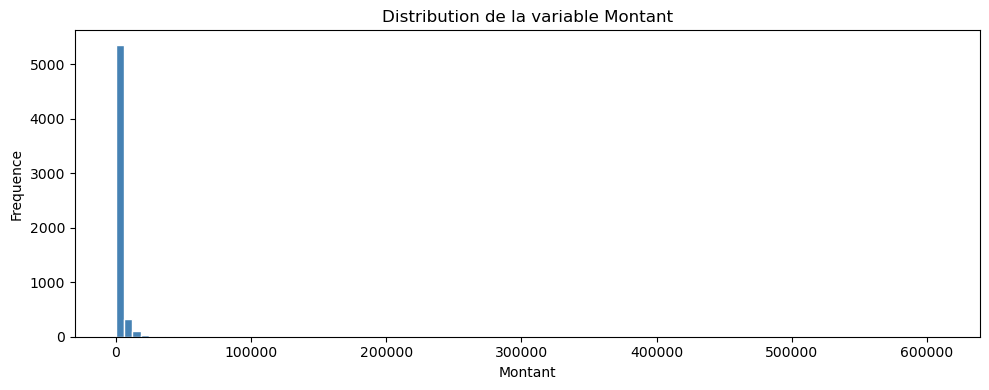

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(rfm['Montant'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution de la variable Montant')
plt.xlabel('Montant')
plt.ylabel('Frequence')
plt.tight_layout()
plt.show()

In [30]:
### Q7 - Analyse de la distribution : Observez-vous une asymetrie ?

In [31]:
from scipy import stats

skewness = rfm['Montant'].skew()
print(f"Skewness (asymetrie): {skewness:.2f}")

if skewness > 1:
    print("=> Distribution fortement asymetrique a droite")
    print("=> Une transformation logarithmique est necessaire")

Skewness (asymetrie): 25.31
=> Distribution fortement asymetrique a droite
=> Une transformation logarithmique est necessaire


In [32]:
### Q8 - Transformation Log : Appliquez une transformation logarithmique

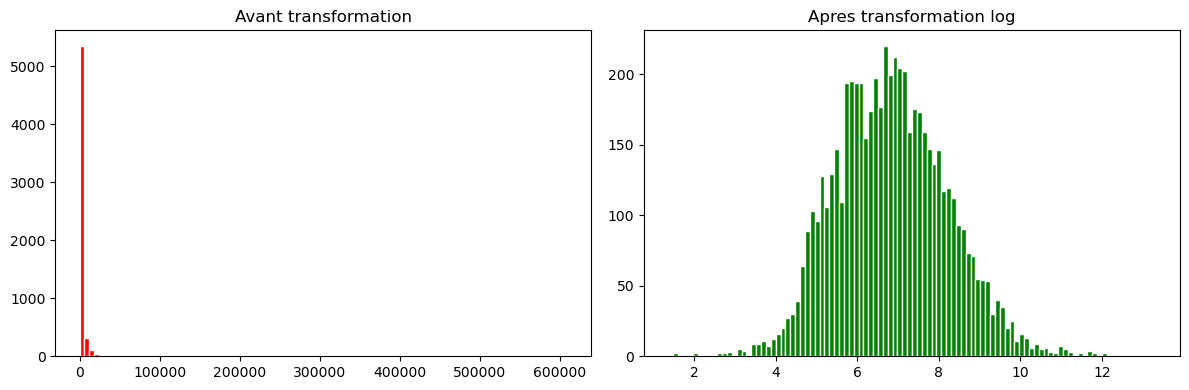

In [33]:
import numpy as np

# Transformation log(x+1)
rfm['R_log'] = np.log1p(rfm['Recence'])
rfm['F_log'] = np.log1p(rfm['Frequence'])
rfm['M_log'] = np.log1p(rfm['Montant'])

# Visualisation avant/apres
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rfm['Montant'], bins=100, color='red', edgecolor='white')
axes[0].set_title('Avant transformation')

axes[1].hist(rfm['M_log'], bins=100, color='green', edgecolor='white')
axes[1].set_title('Apres transformation log')

plt.tight_layout()
plt.show()

In [34]:
### Q9 - Standardisation : Utilisez StandardScaler

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['R_log', 'F_log', 'M_log']])

print("Standardisation terminee!")
print(f"Mean: {rfm_scaled.mean(axis=0).round(2)}")
print(f"Std:  {rfm_scaled.std(axis=0).round(2)}")

Standardisation terminee!
Mean: [-0.  0. -0.]
Std:  [1. 1. 1.]


In [36]:
## Phase 4 : Clustering et Optimisation

### Q10 - Recherche du K optimal : Elbow Method

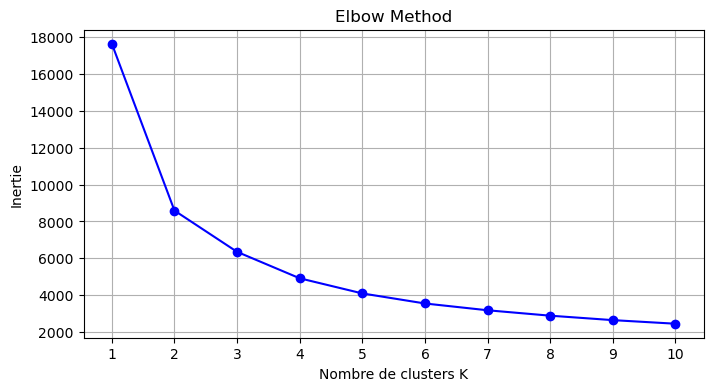

In [37]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Inertie')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [38]:
### Q11 - Validation : Silhouette Score

K=2 : 0.4381
K=3 : 0.3478
K=4 : 0.3653
K=5 : 0.3421
K=6 : 0.3336
K=7 : 0.3052
K=8 : 0.2970
K=9 : 0.2913
K=10 : 0.2918


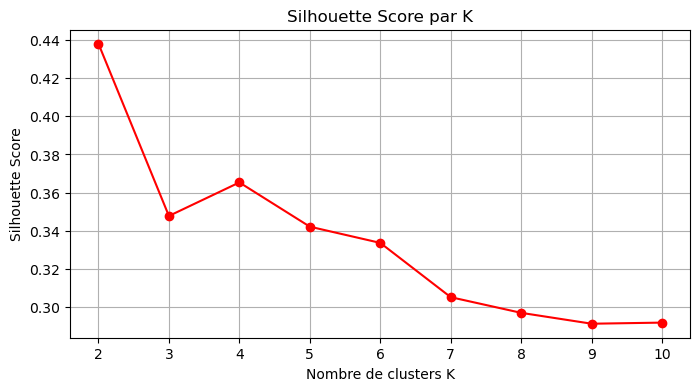

In [39]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k} : {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Nombre de clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score par K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [40]:
### Q12 - Application : Entrainer le modele K-Means final avec K=4

In [41]:
# Modele final avec K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

print("K-Means entraine avec K=4")
print(rfm['Cluster'].value_counts().sort_index())

K-Means entraine avec K=4
Cluster
0    1188
1    1974
2    1465
3    1251
Name: count, dtype: int64


In [42]:
### Q13 - Analysez les moyennes de R, F et M pour chaque cluster

In [43]:
analyse = rfm.groupby('Cluster')[['Recence', 'Frequence', 'Montant']].mean().round(2)
print(analyse)

         Recence  Frequence   Montant
Cluster                              
0          27.43      19.34  11014.37
1         395.86       1.38    325.75
2         227.87       5.10   2002.10
3          28.44       3.04    865.11


In [44]:
### Q14 - Profilage : Identifiez les clusters Champions et Clients a Risque

In [45]:
cluster_names = {
    0: 'Champions',
    1: 'Clients a Risque',
    2: 'Clients Endormis',
    3: 'Nouveaux Clients'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)
print(rfm['Segment'].value_counts())

Segment
Clients a Risque    1974
Clients Endormis    1465
Nouveaux Clients    1251
Champions           1188
Name: count, dtype: int64


In [46]:
## Phase 5 : Decouverte de Connaissances (Data Storytelling)

### Q15 - Action Commerciale : Strategie marketing

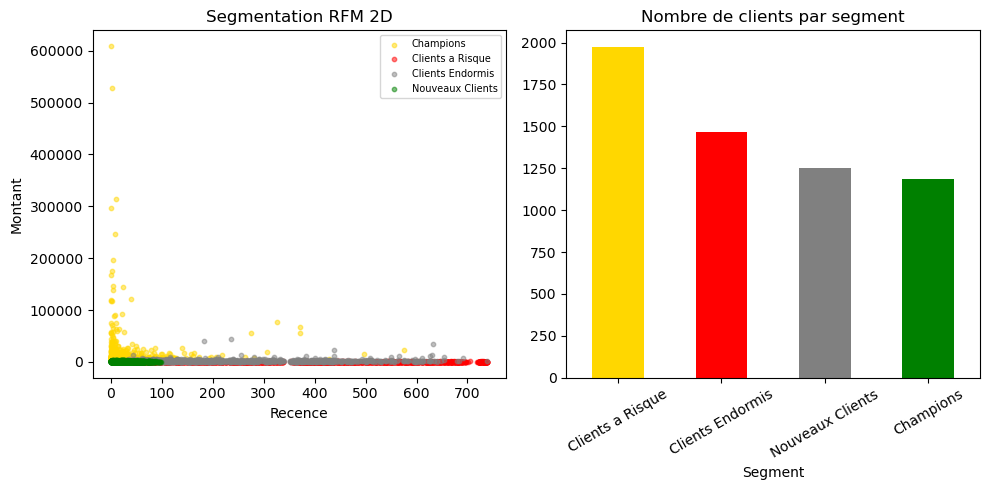


Strategie Marketing:
Champions    -> Programme de fidelite VIP
Clients a Risque -> Campagne de re-engagement
Clients Endormis -> Offres promotionnelles
Nouveaux Clients -> Onboarding personnalise


In [47]:
colors = ['gold', 'red', 'gray', 'green']

plt.figure(figsize=(10, 5))

# Visualisation 2D
plt.subplot(1, 2, 1)
for i, (name, color) in enumerate(zip(cluster_names.values(), colors)):
    mask = rfm['Cluster'] == i
    plt.scatter(rfm[mask]['Recence'], rfm[mask]['Montant'], 
                label=name, alpha=0.5, color=color, s=10)
plt.xlabel('Recence')
plt.ylabel('Montant')
plt.title('Segmentation RFM 2D')
plt.legend(fontsize=7)

# Strategie
plt.subplot(1, 2, 2)
rfm['Segment'].value_counts().plot(kind='bar', color=colors)
plt.title('Nombre de clients par segment')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print("\nStrategie Marketing:")
print("Champions    -> Programme de fidelite VIP")
print("Clients a Risque -> Campagne de re-engagement")
print("Clients Endormis -> Offres promotionnelles")
print("Nouveaux Clients -> Onboarding personnalise")